In [2]:
import pandas as pd 
import numpy as np


In [3]:
df=pd.read_csv("Machine.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [5]:
#value counts of each column for machine failure column
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [6]:
df=df.drop(['UDI','Product ID','TWF','HDF','PWF','RNF','OSF'],axis=1)
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [7]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Type']=le.fit_transform(df['Type'])
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,2,298.1,308.6,1551,42.8,0,0
1,1,298.2,308.7,1408,46.3,3,0
2,1,298.1,308.5,1498,49.4,5,0
3,1,298.2,308.6,1433,39.5,7,0
4,1,298.2,308.7,1408,40.0,9,0


In [8]:
#separating the features and target variable
X=df.drop('Machine failure',axis=1)
y=df['Machine failure']
print("Features:")
print(X.columns)
print("\nTarget variable:")
print(y.name)

Features:
Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'],
      dtype='object')

Target variable:
Machine failure


In [9]:
#splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (8000, 6)
Testing set size: (2000, 6)


In [10]:
#feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Decision Tree Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Classifier:
Accuracy: 0.973
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.77      0.29      0.43        68

    accuracy                           0.97      2000
   macro avg       0.87      0.65      0.71      2000
weighted avg       0.97      0.97      0.97      2000

Confusion Matrix:
[[1926    6]
 [  48   20]]


<Axes: >

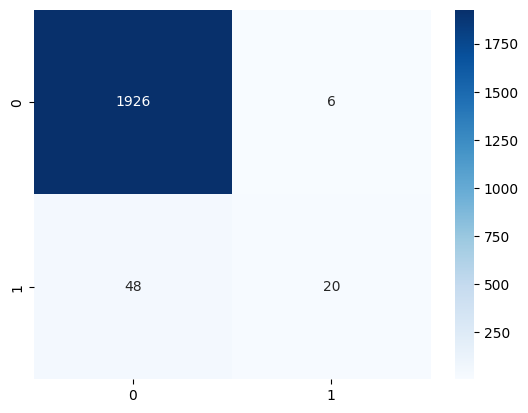

In [24]:
#confusion matrix
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')

In [21]:
#predicting on new data
new_data = pd.DataFrame({
    'Type': [1],  # Example value for Type
    'Air temperature [K]': [300],  # Example value for Air temperature
    'Process temperature [K]': [310],  # Example value for Process temperature
    'Rotational speed [rpm]': [1500],  # Example value for Rotational speed
    'Torque [Nm]': [50],  # Example value for Torque
    'Tool wear [min]': [100]  # Example value for Tool wear
})

new_data_scaled = scaler.transform(new_data)
new_prediction = dt.predict(new_data_scaled)
new_prediction_proba = dt.predict_proba(new_data_scaled)[:, 1]

#printing the prediction result
print("Prediction for new data:", new_prediction)
print("Prediction probability for new data:", new_prediction_proba)


Prediction for new data: [0]
Prediction probability for new data: [0.00263036]


In [20]:
#another prediction for new data(true)
new_data_3 = pd.DataFrame({
    'Type': [3],  # Example value for Type
    'Air temperature [K]': [320],  # Example value for Air temperature
    'Process temperature [K]': [330],  # Example value for Process temperature
    'Rotational speed [rpm]': [1700],  # Example value for Rotational speed
    'Torque [Nm]': [70],  # Example value for Torque
    'Tool wear [min]': [140]  # Example value for Tool wear
})

new_data_3_scaled = scaler.transform(new_data_3)
new_prediction_3 = dt.predict(new_data_3_scaled)
new_prediction_proba_3 = dt.predict_proba(new_data_3_scaled)[:, 1]

# printing the prediction and probability for the third new data
print("Prediction for new data 2:", new_prediction_3)
print("Prediction probability for new data 2:", new_prediction_proba_3)


Prediction for new data 2: [1]
Prediction probability for new data 2: [1.]
